# exercise 6

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import factorial

## Part 1

In [3]:
np.random.seed(42)
lamb = 1
m_servers = 10
mean_service_time = 8
mean_time_between_customers = 1
customers = 10_000
n_reps = 10

A = lamb * mean_service_time

def g(i):
    return A**i / factorial(i)


samples = np.zeros(customers, dtype=int)

x = 0

for t in range(customers):
    delta = np.random.choice([-1, 1], p=[0.5, 0.5])
    y = x + delta

    # reject if outside support
    if y < 0 or y > m_servers:
        samples[t] = x
        continue

    # acceptance probability
    alpha = min(1, g(y) / g(x))

    if np.random.rand() < alpha:
        x = y

    samples[t] = x


p = np.array([g(i) for i in range(m_servers+1)])
p /= np.sum(p)

observed = np.bincount(samples, minlength=m_servers+1)

expected = customers * p

chi2, pvalue = stats.chisquare(observed, expected)

print("chi2 =", chi2)
print("p-value =", pvalue)

chi2 = 16.54738957284451
p-value = 0.08499849063236509


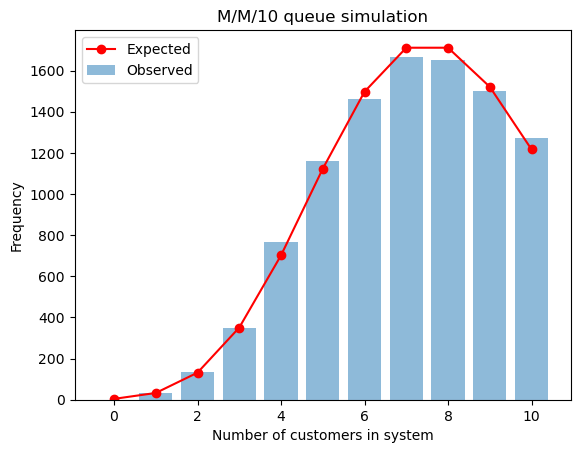

In [4]:
plt.bar(range(m_servers+1), observed, alpha=0.5, label="Observed")
plt.plot(range(m_servers+1), expected, 'ro-', label="Expected")
plt.xlabel("Number of customers in system")
plt.ylabel("Frequency")
plt.title("M/M/10 queue simulation")
plt.legend()
plt.show()

## part 2

### a

In [5]:
np.random.seed(42)

A1 = 4
A2 = 4
m = 10
customers = 10_000

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

moves = np.array([
    [-1,  0],
    [ 1,  0],
    [ 0, -1],
    [ 0,  1],
    [-1, -1],
    [-1,  1],
    [ 1, -1],
    [ 1,  1]
])

samples = np.zeros((customers, 2), dtype=int)

x = np.array([0, 0])

for t in range(customers):

    delta = moves[np.random.randint(len(moves))]
    y = x + delta

    i, j = y

    if i < 0 or j < 0 or i + j > m:
        samples[t] = x
        continue

    alpha = min(1, g(i, j) / g(x[0], x[1]))

    if np.random.rand() < alpha:
        x = y

    samples[t] = x


states = []
probs = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            probs.append(g(i, j))

states = np.array(states)
p = np.array(probs)
p /= p.sum()

burn_in = 1000
thin = 20

thin_samples = samples[burn_in::thin]

observed = []

for i, j in states:
    observed.append(np.sum((thin_samples[:, 0] == i) & 
                           (thin_samples[:, 1] == j)))

observed = np.array(observed)
expected = len(thin_samples) * p

chi2, pvalue = stats.chisquare(observed, expected)


print("With burn-in =", burn_in, "and thinning =", thin)
print("n used =", len(thin_samples))
print("chi2 =", chi2)
print("p-value =", pvalue)

With burn-in = 1000 and thinning = 20
n used = 450
chi2 = 66.73076510416666
p-value = 0.4172801938280032


### b

In [6]:
np.random.seed(42)
A1 = A2 = 4
m = 10

def g(i,j):
    return (A1**i / factorial(i)) * (A2**j/ factorial(j))


samples = np.zeros((customers,2), dtype=int)

x = np.zeros(2, dtype=int)

for t in range(customers):
    # choose whether to change i or j
    coord = np.random.choice([0, 1])

    # move up or down
    step = np.random.choice([-1, 1])

    y = x.copy()
    y[coord] += step

    i, j = y

    # reject if outside allowed state space
    if i < 0 or j < 0 or i + j > m:
        samples[t] = x
        continue

    alpha = min(1, g(i, j) / g(x[0], x[1]))

    if np.random.rand() < alpha:
        x = y

    samples[t] = x


states = []
probs = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            probs.append(g(i, j))

states = np.array(states)
p = np.array(probs)
p = p / p.sum()

observed = []

for i, j in states:
    observed.append(np.sum((samples[:, 0] == i) & (samples[:, 1] == j)))

observed = np.array(observed)
expected = customers * p

chi2, pvalue = stats.chisquare(observed, expected)

print("chi2 =", chi2)
print("p-value =", pvalue)


print("----------------------with thining and burn-in-------------------")
burn_in = 1000
thin = 20

thin_samples = samples[burn_in::thin]

observed = []

for i, j in states:
    observed.append(np.sum((thin_samples[:, 0] == i) & 
                           (thin_samples[:, 1] == j)))

observed = np.array(observed)
expected = len(thin_samples) * p

chi2, pvalue = stats.chisquare(observed, expected)

print("n used =", len(thin_samples))
print("chi2 =", chi2)
print("p-value =", pvalue)

chi2 = 306.41356151998076
p-value = 5.4020153188294646e-33
----------------------with thining and burn-in-------------------
n used = 450
chi2 = 74.52346268954267
p-value = 0.19614581583875154


### c

In [7]:
np.random.seed(42)
A1 = 4
A2 = 4
m = 10
N = 10_000

samples = np.zeros((N, 2), dtype=int)

i, j = 0, 0

for t in range(N):

    # sample i | j
    possible_i = np.arange(m - j + 1)
    probs_i = np.array([A1**x / factorial(x) for x in possible_i])
    probs_i = probs_i / probs_i.sum()

    i = np.random.choice(possible_i, p=probs_i)

    # sample j | i
    possible_j = np.arange(m - i + 1)
    probs_j = np.array([A2**y / factorial(y) for y in possible_j])
    probs_j = probs_j / probs_j.sum()

    j = np.random.choice(possible_j, p=probs_j)

    samples[t] = [i, j]


states = []
probs = []

for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            states.append((i, j))
            probs.append((A1**i / factorial(i)) * (A2**j / factorial(j)))

states = np.array(states)
p = np.array(probs)
p = p / p.sum()

observed = []

for i, j in states:
    observed.append(np.sum((samples[:, 0] == i) & (samples[:, 1] == j)))

observed = np.array(observed)
expected = N * p

chi2, pvalue = stats.chisquare(observed, expected)

print("chi2 =", chi2)
print("p-value =", pvalue)

chi2 = 69.38809106029693
p-value = 0.33188342758229766


## Part 3

### a

In [ ]:
np.random.seed(42)
rho = 1/2
cov = np.array([[1, rho], [rho, 1]])
xi_true, gamma_true = np.random.multivariate_normal(mean=[0, 0], cov=cov)
theta_true, psi_true = np.exp(xi_true), np.exp(gamma_true)

print(f"True parameters: theta = {theta_true:.4f}, psi = {psi_true:.4f}")


True parameters: theta = 0.6970, psi = 0.6070


In [24]:
np.random.seed(42)
Z1 = np.random.normal(0,1)
Z2 = np.random.normal(0,1)

xi = Z1
gamma = rho * Z1 + np.sqrt(1 - rho**2) * Z2
theta = np.exp(xi)
psi = np.exp(gamma)
print(f"Sampled parameters: theta = {theta:.4f}, psi = {psi:.4f}")

Sampled parameters: theta = 1.6433, psi = 1.1373


### b

In [9]:
np.random.seed(42)
n = 10
X_bay = np.random.normal(theta_true,np.sqrt(theta_true),n)
print("Bayesian samples:", X_bay)

Bayesian samples: [1.11163056 0.58152635 1.23766973 1.96843801 0.5014745  0.5014882
 2.01534169 1.33763841 0.30501955 1.14990445]


### c

In [10]:
import numpy as np

def posterior(theta, psi, x, prior):
    """
    theta : mean parameter
    psi   : variance parameter (>0)
    x     : sample
    prior : function prior(theta, psi)
    """

    n = len(x)

    likelihood = (
        psi ** (-n / 2)
        * np.exp(-np.sum((x - theta) ** 2) / (2 * psi))
    )

    return likelihood * prior(theta, psi)


In [11]:
def log_posterior(theta, psi, x, log_prior):
    if psi <= 0:
        return -np.inf

    n = len(x)

    log_likelihood = (
        -n / 2 * np.log(psi)
        - np.sum((x - theta) ** 2) / (2 * psi)
    )

    return log_likelihood + log_prior(theta, psi)

### d

In [12]:
np.random.seed(42)
def metropolis_hastings(x, prior, N=10000, init=(0.0, 1.0),
                        proposal_sd=(0.5, 0.3)):

    samples = np.zeros((N, 2))
    state = np.array(init)   # state = (theta, psi)

    for t in range(N):

        # propose new (theta, psi)
        proposal = state + np.random.normal(0, proposal_sd)

        theta_new, psi_new = proposal

        # psi must be positive
        if psi_new <= 0:
            samples[t] = state
            continue

        # acceptance probability
        alpha = min(
            1,
            posterior(theta_new, psi_new, x, prior)
            / posterior(state[0], state[1], x, prior)
        )

        # accept or reject
        if np.random.rand() < alpha:
            state = proposal

        samples[t] = state

    return samples


def prior(theta, psi):
    return 1 / psi if psi > 0 else 0

np.random.seed(42)

n = 10

x = np.random.normal(theta_true, np.sqrt(psi_true), size=n)

samples = metropolis_hastings(x, prior, N=10000)

burn_in = 1000
thin = 10

mcmc_samples = samples[burn_in::thin]

print("Posterior mean theta:", np.mean(mcmc_samples[:, 0]))
print("Posterior mean psi:", np.mean(mcmc_samples[:, 1]))

Posterior mean theta: 1.0482273212111992
Posterior mean psi: 0.39624588705074415


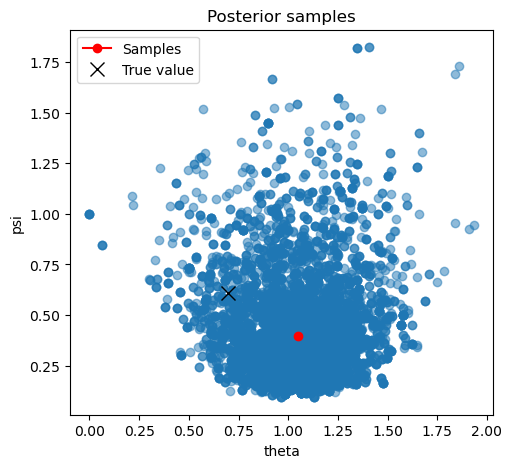

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.plot(np.mean(mcmc_samples[:, 0]), np.mean(mcmc_samples[:, 1]), 'ro-', label="Samples")
plt.plot(theta_true, psi_true, 'kx', label="True value", markersize=10)
plt.xlabel("theta")
plt.ylabel("psi")
plt.title("Posterior samples")
plt.legend()
plt.show()

### e

/var/folders/dk/qfjqr2sx37v3tfj6lp59zmgr0000gn/T/ipykernel_28440/742103162.py:14: RuntimeWarning: overflow encountered in scalar power
  psi ** (-n / 2)
/var/folders/dk/qfjqr2sx37v3tfj6lp59zmgr0000gn/T/ipykernel_28440/742103162.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  psi ** (-n / 2)
/var/folders/dk/qfjqr2sx37v3tfj6lp59zmgr0000gn/T/ipykernel_28440/1691490409.py:23: RuntimeWarning: invalid value encountered in scalar divide
  posterior(theta_new, psi_new, x, prior)
/var/folders/dk/qfjqr2sx37v3tfj6lp59zmgr0000gn/T/ipykernel_28440/1691490409.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  posterior(theta_new, psi_new, x, prior)


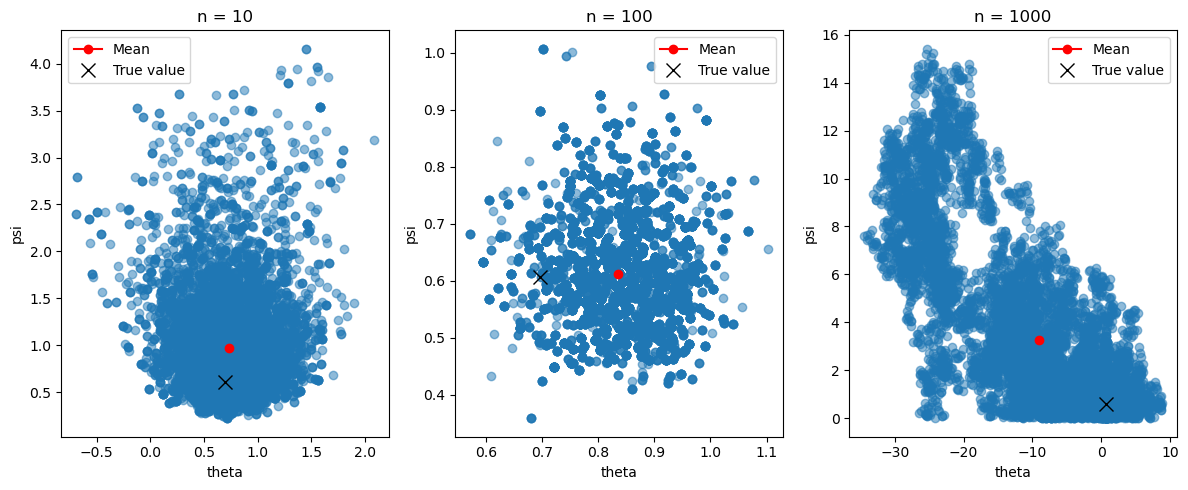

In [14]:
n = [10, 100, 1000]

samples_list = []
means = []
for i in n:

    x = np.random.normal(theta_true, np.sqrt(psi_true), size=i)

    samples = metropolis_hastings(x, prior, N=10000)

    burn_in = 1000
    thin = 10

    mcmc_samples = samples[burn_in::thin]
    samples_list.append(samples)
    means.append(np.mean(mcmc_samples, axis=0))

plt.figure(figsize=(12, 5))
for i, samples in enumerate(samples_list):
    plt.subplot(1, len(n), i+1)
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
    plt.plot(means[i][0], means[i][1], 'ro-', label="Mean")
    plt.plot(theta_true, psi_true, 'kx', label="True value", markersize=10)
    plt.xlabel("theta")
    plt.ylabel("psi")
    plt.title(f"n = {n[i]}")
    plt.legend()
plt.tight_layout()
plt.show()

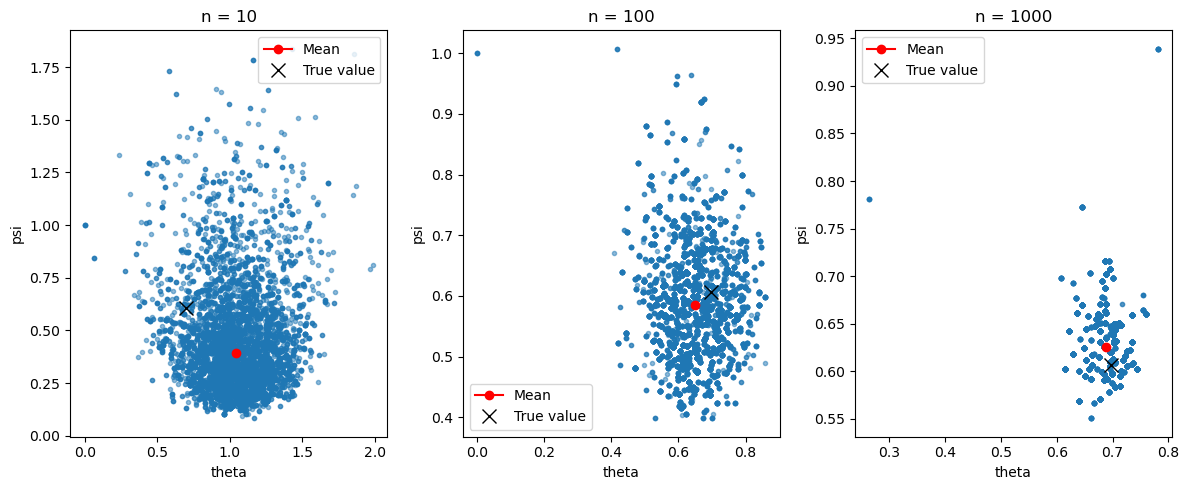

In [26]:
np.random.seed(42)
def metropolis_hastings(x, log_prior, N=10000, init=(0.0, 1.0),
                        proposal_sd=(0.5, 0.3)):

    samples = np.zeros((N, 2))
    state = np.array(init)

    current_log_post = log_posterior(state[0], state[1], x, log_prior)

    for t in range(N):

        proposal = state + np.random.normal(0, proposal_sd)
        theta_new, psi_new = proposal

        proposed_log_post = log_posterior(theta_new, psi_new, x, log_prior)

        log_alpha = proposed_log_post - current_log_post

        if np.log(np.random.rand()) < log_alpha:
            state = proposal
            current_log_post = proposed_log_post

        samples[t] = state

    return samples


def log_prior(theta, psi):
    return -np.log(psi) if psi > 0 else -np.inf


n = [10, 100, 1000]

samples_list = []
means = []
for i in n:

    x = np.random.normal(theta_true, np.sqrt(psi_true), size=i)

    samples = metropolis_hastings(x, log_prior, N=10000)

    burn_in = 1000
    thin = 10

    mcmc_samples = samples[burn_in::thin]
    samples_list.append(samples)
    means.append(np.mean(mcmc_samples, axis=0))

plt.figure(figsize=(12, 5))
for i, samples in enumerate(samples_list):
    plt.subplot(1, len(n), i+1)
    plt.scatter(samples[:, 0], samples[:, 1],marker = '.',alpha=0.5)
    plt.plot(means[i][0], means[i][1], 'ro-', label="Mean")
    plt.plot(theta_true, psi_true, 'kx', label="True value", markersize=10)
    plt.xlabel("theta")
    plt.ylabel("psi")
    plt.title(f"n = {n[i]}")
    plt.legend()
plt.tight_layout()
plt.show()